# Classification Chats vs Chiens - CNN Simple

Ce notebook realise une classification binaire d'images (chat ou chien) en plusieurs etapes. Chaque etape est expliquee en detail pour comprendre ce que fait le code et pourquoi.

## Etape 1 : Import des bibliotheques et configuration

On importe les modules Python necessaires et on definit les parametres globaux. Ces variables determinent le chemin des donnees, la taille des images, et combien d'images charger par classe.

In [17]:
# Bibliotheques pour le calcul numerique (numpy), l'apprentissage profond (tensorflow/keras),
# les graphiques (matplotlib), et la manipulation de fichiers (pathlib, zipfile, PIL)

import os

from keras.src.applications.mobilenet_v2 import MobileNetV2

os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
from PIL import Image

tf.keras.backend.clear_session()

tf.random.set_seed(42)
np.random.seed(42)

print("XLA enabled:", tf.config.optimizer.get_experimental_options().get("jit_compile", False))

tf.keras.mixed_precision.set_global_policy('mixed_float16')
gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
# Configuration : chemin du fichier zip contenant les images
ZIP_PATH = 'kagglecatsanddogs_5340.zip'
# Dossier ou extraire les images
DATA_DIR = 'cats_dogs_data'
# Taille cible des images en pixels (largeur et hauteur). Toutes les images seront redimensionnees
# a 128x128 pour que le modele ait des entrees de taille fixe
IMG_SIZE = 128
# Nombre max d'images a charger par classe (Chat et Chien). Limiter reduit le temps d'entrainement
# mais moins de donnees peut diminuer la precision. Augmenter a 5000+ pour de meilleurs resultats
MAX_IMAGES_PER_CLASS = 2000

XLA enabled: False


## Etape 2 : Extraction et chargement des donnees

On extrait le fichier zip si necessaire, puis on charge les images. Chaque image est convertie en RGB et redimensionnee. Les etiquettes (labels) : 0 pour Chat, 1 pour Chien.

In [18]:
%%time
def load_cats_dogs(zip_path=ZIP_PATH, data_dir=DATA_DIR, img_size=IMG_SIZE, max_per_class=MAX_IMAGES_PER_CLASS):
    """
    Extrait le zip et charge les images de chats et chiens.
    Retourne X (tableau d'images) et y (etiquettes : 0=Chat, 1=Chien).
    """
    # Extraire le zip uniquement si le dossier de donnees n'existe pas encore
    if Path(data_dir).exists() is False:
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(data_dir)
    
    base = Path(data_dir) / 'PetImages'
    X, y = [], []
    for label, folder in enumerate(['Cat', 'Dog']):  # label 0 = Chat, 1 = Chien
        folder_path = base / folder
        if not folder_path.exists():
            continue
        count = 0
        for img_path in sorted(folder_path.glob('*.jpg')):
            if count >= max_per_class:
                break
            try:
                img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
                X.append(np.array(img))  # Conversion PIL -> numpy
                y.append(label)
                count += 1
            except Exception:
                pass
    return np.array(X), np.array(y)

X_raw, y = load_cats_dogs()
print(f"Charge : {X_raw.shape[0]} images, forme {X_raw.shape[1:]}")
print(f"Classes : Chat=0, Chien=1 | Effectifs : Chat={np.sum(y==0)}, Chien={np.sum(y==1)}")

Charge : 4000 images, forme (128, 128, 3)
Classes : Chat=0, Chien=1 | Effectifs : Chat=2000, Chien=2000
CPU times: user 9.44 s, sys: 1.24 s, total: 10.7 s
Wall time: 25.1 s


## Etape 3 : Visualisation d'exemples d'images

On affiche 10 images (5 chats, 5 chiens) pour verifier que le chargement s'est bien passe et voir a quoi ressemblent les donnees.

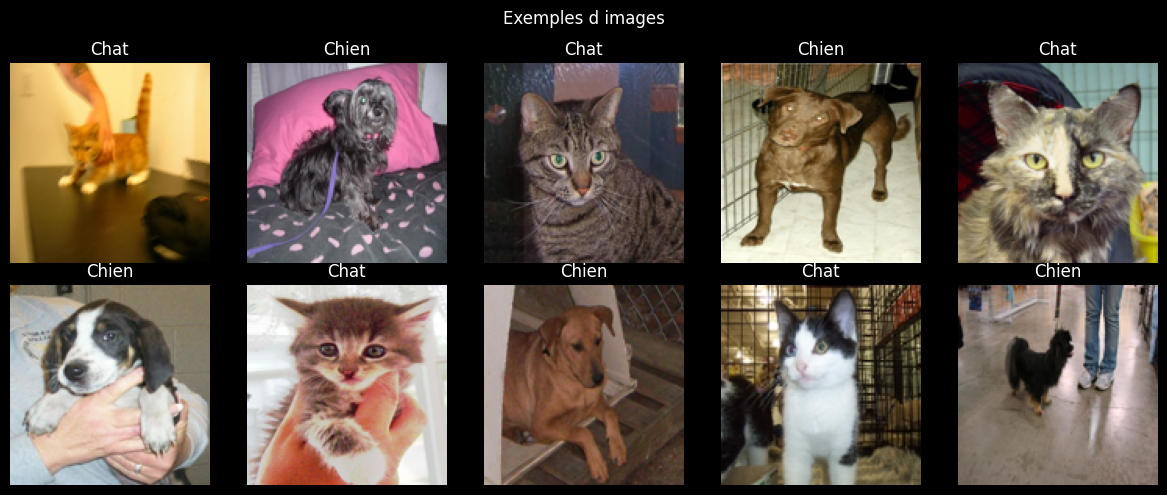

In [19]:
# Creer une grille 2 lignes x 5 colonnes pour afficher 10 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    # i % 2 donne 0 ou 1 (alternance Chat/Chien), i // 2 donne l'indice dans la classe
    idx = np.where(y == i % 2)[0][i // 2]
    ax.imshow(X_raw[idx])
    ax.set_title('Chat' if y[idx] == 0 else 'Chien')
    ax.axis('off')
plt.suptitle('Exemples d images', fontsize=12)
plt.tight_layout()
plt.show()

## Etape 4 : Pre-traitement - Normalisation des pixels

Les pixels bruts sont des entiers entre 0 et 255. On les divise par 255 pour obtenir des valeurs entre 0 et 1. Cela stabilise l'entrainement du reseau de neurones : des valeurs trop grandes peuvent faire diverger les poids.

In [20]:
# Conversion en float et normalisation : valeurs de pixels entre 0 et 1
X = X_raw.astype(np.float32) / 255.0
print(f"Plage des pixels apres normalisation : [{X.min():.2f}, {X.max():.2f}]")

Plage des pixels apres normalisation : [0.00, 1.00]


## Etape 5 : Division train / validation / test

On separe les donnees en trois ensembles :
- **Train** : pour entrainer le modele (le modele apprend sur ces images)
- **Validation** : pour suivre la performance pendant l'entrainement et arreter au bon moment (eviter l'overfitting)
- **Test** : pour evaluer le modele a la fin sur des images jamais vues

stratify=y garantit que la proportion Chat/Chien reste la meme dans chaque ensemble. random_state=42 assure la reproductibilite.

In [21]:
from sklearn.model_selection import train_test_split

# D'abord isoler 15% pour le test (donnees jamais vues jusqu'a la fin)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
# Puis diviser le reste : 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42)

print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

Train : 2720 | Val : 680 | Test : 600


## Etape 6 : Construction du modele CNN

Un CNN (Reseau de Neurones Convolutionnel) est adapte aux images. Structure :
- **Conv2D** : detecte des motifs locaux (bords, textures)
- **MaxPool2D** : reduit la taille spatiale, garde les caracteristiques les plus fortes
- **Flatten** : aplatit en une ligne pour les couches denses
- **Dense** : neurones classiques pour la decision finale
- **Dropout** : desactive aleatoirement 50% des neurones a chaque pas pour eviter l'overfitting
- **sigmoid** : sortie entre 0 et 1 (probabilite "Chien"). > 0.5 = Chien, <= 0.5 = Chat

**Parametres a experimenter :** IMG_SIZE (plus grand = plus de details), nombre de filtres Conv2D (32/64/128), Dense(128), Dropout(0.5), learning_rate(0.001). Voir commentaires dans le code.

In [22]:
from keras.src.legacy.preprocessing.image import ImageDataGenerator

batch_size = 64
from keras.applications import MobileNetV2
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
base_model.trainable = False

model = keras.Sequential([



    #Augmentation layers
    keras.layers.RandomRotation(0.35, fill_mode='nearest',interpolation='nearest'),
    keras.layers.RandomTranslation(0.2, 0.0, fill_mode='nearest',interpolation='nearest'),
    keras.layers.RandomTranslation(0.0, 0.2, fill_mode='nearest',interpolation='nearest'),
    keras.layers.RandomZoom([-0.2,0.2], fill_mode='nearest',interpolation='nearest'),
    keras.layers.RandomFlip("horizontal"),

    base_model,
    keras.layers.GlobalAveragePooling2D(),

    #Convolutional layers
    # keras.layers.Conv2D(32, 3, activation='relu'),      # ASTUCE: 32 filtres -> essayer 16, 64
    # keras.layers.MaxPool2D(2),                          # Reduction 2x2
    # keras.layers.Conv2D(64, 3, activation='relu'),      # ASTUCE: progression 32->64->128 peut etre modifiee
    # keras.layers.MaxPool2D(2),                          # ASTUCE: pool 3 pour reduction plus forte
    # keras.layers.Conv2D(128, 3, activation='relu'),
    # keras.layers.MaxPool2D(2),

    #Dense layers

    #keras.layers.Flatten(),                             # Conversion 2D -> 1D
    keras.layers.Dense(128, activation='relu'),         # ASTUCE: 64 ou 256 selon capacite souhaitee
    keras.layers.Dropout(0.5),                          # ASTUCE: 0.3-0.4 si sous-apprentissage, 0.6 si overfitting
    keras.layers.Dense(1, activation='sigmoid')         # Sortie binaire : probabilite Chien
])

# Compilation : on choisit la fonction de perte (binary_crossentropy pour binaire),
# l'optimiseur (Adam) et la metrique a afficher (accuracy)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # ASTUCE: 0.0005 si instable, 0.002 si trop lent
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Etape 7 : Augmentation des donnees et callbacks

**Augmentation** : on applique des transformations aleatoires (rotation, decalage, zoom, retournement) pour creer des variantes des images d'entrainement. Cela aide le modele a generaliser et evite l'overfitting.

**aug_generator** : genere des lots d'images augmentees indefiniment (Keras exige un generateur qui ne s'epuise pas).

**EarlyStopping** : arrete l'entrainement si val_loss ne s'ameliore pas pendant 8 epochs. restore_best_weights recharge les meilleurs poids.

**ReduceLROnPlateau** : divise le learning rate par 2 si val_loss stagne pendant 4 epochs. Un LR plus bas permet un affinage fin.

**Parametres a ajuster :** rotation_range, zoom_range (augmenter si overfitting). patience de EarlyStopping (augmenter si entrainement s'arrete trop tot). batch_size (32) : plus grand = courbes plus stables mais plus de memoire.

In [23]:


import os
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'  # Disable XLA
#tf.keras.mixed_precision.set_global_policy('mixed_float16')
tf.config.optimizer.set_jit(False)  # Force-disable XLA


early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
)  # factor=0.5 : divise LR par 2 ; patience=4 : attend 4 epochs sans amelioration


## Etape 8 : Entrainement du modele

model.fit lance l'entrainement. steps_per_epoch = nombre de lots par epoch. validation_data permet de calculer val_loss et val_accuracy a chaque epoch. Les callbacks (early_stop, reduce_lr) sont appliques automatiquement.

In [24]:
%%time
# history contient loss, accuracy, val_loss, val_accuracy pour chaque epoch
history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    #steps_per_epoch=max(1, len(X_train) // batch_size),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - accuracy: 0.7548 - loss: 0.4950 - val_accuracy: 0.9279 - val_loss: 0.1786 - learning_rate: 0.0010
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8452 - loss: 0.3552 - val_accuracy: 0.9353 - val_loss: 0.1607 - learning_rate: 0.0010
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8313 - loss: 0.3676 - val_accuracy: 0.9382 - val_loss: 0.1564 - learning_rate: 0.0010
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8438 - loss: 0.3467 - val_accuracy: 0.9368 - val_loss: 0.1715 - learning_rate: 0.0010
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8445 - loss: 0.3414 - val_accuracy: 0.9368 - val_loss: 0.1542 - learning_rate: 0.0010
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8555 - loss: 0.3290 - val_accuracy: 0.9382 - val_loss: 0.1475 - learning_rate: 0.0010
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8463 - loss: 0.3396 - val_

## Etape 9 : Graphiques de la perte et de la precision

**Variables des graphiques :**
- **Axe X (Epoch)** : numero du passage complet sur les donnees d'entrainement
- **loss (perte train)** : erreur sur les images d'entrainement. On veut qu'elle diminue
- **val_loss (perte validation)** : erreur sur les images de validation. On veut qu'elle diminue et suive la loss
- **accuracy** : pourcentage de bonnes reponses sur le train
- **val_accuracy** : pourcentage de bonnes reponses sur la validation

**Signes d'overfitting a surveiller :**
- loss continue de baisser alors que val_loss remonte ou stagne
- accuracy monte alors que val_accuracy stagne ou baisse
- Un ecart croissant entre les courbes train et validation indique que le modele memorise le train au lieu de generaliser

**Bon equilibre :** les deux courbes (train et validation) evoluent ensemble, val_loss reste proche de loss, val_accuracy suit accuracy.

**Conseils selon ce que vous observez :**
- val_loss remonte (overfitting) : augmenter Dropout, reduire les couches/neurones, plus d'augmentation
- Les deux courbes restent hautes (sous-apprentissage) : plus d'epochs, modele plus complexe, learning_rate plus eleve
- Courbes tres irregulieres : reduire learning_rate, augmenter batch_size

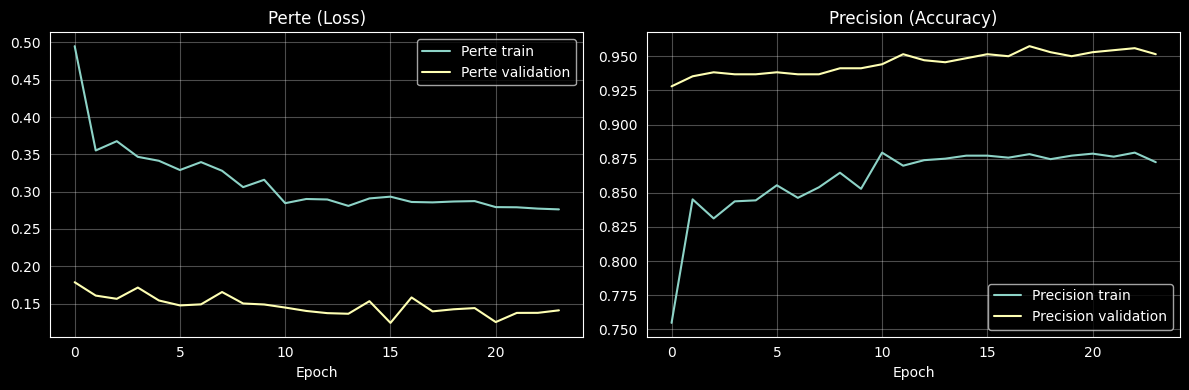

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : Perte (Loss). Plus c'est bas, mieux c'est.
# Si val_loss remonte alors que loss descend : overfitting -> augmenter Dropout ou epochs
axes[0].plot(history.history['loss'], label='Perte train')
axes[0].plot(history.history['val_loss'], label='Perte validation')
axes[0].set_title('Perte (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Precision. Plus c'est haut, mieux c'est.
# Si val_accuracy stagne bien en dessous de accuracy : overfitting
axes[1].plot(history.history['accuracy'], label='Precision train')
axes[1].plot(history.history['val_accuracy'], label='Precision validation')
axes[1].set_title('Precision (Accuracy)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Etape 10 : Evaluation sur le jeu de test

On evalue le modele sur des images jamais vues (test set). C'est la mesure finale de la qualite. Un ecart modere entre precision train et test est normal. Un ecart tres grand indique de l'overfitting.

In [26]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nPrecision sur le jeu de test : {test_acc*100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - accuracy: 0.9517 - loss: 0.1286

Precision sur le jeu de test : 95.17%


**Rapport de classification - Definitions :**
- **Precision** : parmi les images predites comme Chien (ou Chat), combien sont reellement des Chiens (ou Chats). Precision haute = peu de faux positifs.
- **Recall (Rappel)** : parmi les vrais Chiens (ou Chats), combien ont ete correctement identifies. Recall haut = peu de faux negatifs.
- **F1-score** : moyenne harmonique de precision et recall. Metrique globale pour une classe.
- **Support** : nombre d'exemples reels dans le test pour chaque classe.

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

# predict donne une probabilite ; > 0.5 signifie prediction Chien (1), sinon Chat (0)
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Chat', 'Chien']))
# Matrice de confusion : lignes = vraie etiquette, colonnes = prediction
# [[vrais Chats predits Chat, vrais Chats predits Chien], [vrais Chiens predits Chat, vrais Chiens predits Chien]]
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step
Rapport de classification :
              precision    recall  f1-score   support

        Chat       0.95      0.96      0.95       300
       Chien       0.96      0.95      0.95       300

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600

Matrice de confusion :
[[287  13]
 [ 16 284]]


## Etape 11 : Sauvegarde du modele

Sauvegarder le modele permet de le reutiliser plus tard sans le reentrainer (chargement avec keras.models.load_model).

In [28]:
model.save('cats_dogs_model.keras')
print('Modele sauvegarde dans cats_dogs_model.keras')

from keras import backend as K
tf.keras.backend.clear_session()


Modele sauvegarde dans cats_dogs_model.keras


## Etape 12 : Graphiques
Matrice de confusion visuelle

/home/gab/miniconda3/envs/tf_gpu/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step
conf_matrix
[[287  13]
 [ 16 284]]

Heatmap - Values


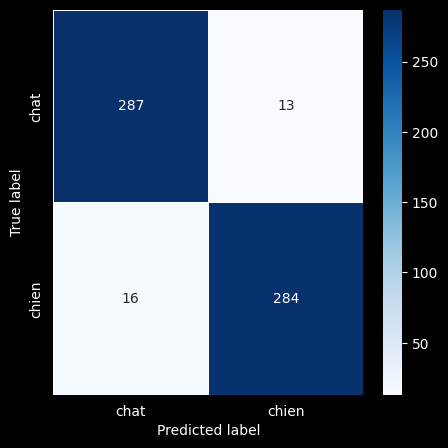


Heatmap - pourcent


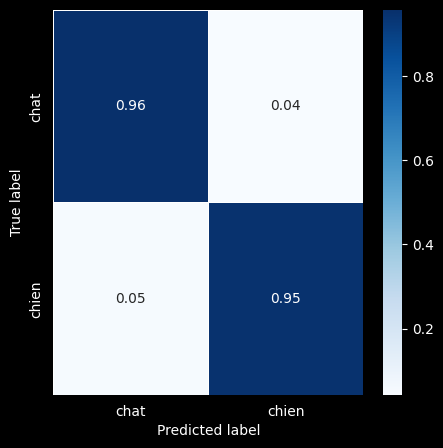

In [29]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

model = keras.models.load_model('cats_dogs_model.keras')
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
# y_test = [1, 1, 0, 0, 1]
# y_pred = [1, 1, 0, 0, 0]
labels = [0, 1]
titles = ["chat", "chien"]
conf_matrix = confusion_matrix(y_test, y_pred, labels=labels)
print("conf_matrix")
print(conf_matrix)
print()

print("Heatmap - Values")
cm = pd.DataFrame(conf_matrix, index=labels, columns=labels)

plt.figure(figsize=[5,5])
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", linewidths=.5, xticklabels=titles, yticklabels=titles)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

print()
print("Heatmap - pourcent")
cm_percent = cm.div(cm.sum(axis=1), axis=0)
plt.figure(figsize=[5,5])
sns.heatmap(cm_percent, annot=True, cmap="Blues", fmt=".2f", linewidths=.5, xticklabels=titles, yticklabels=titles)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## Distribution de confiance du model

/home/gab/miniconda3/envs/tf_gpu/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step


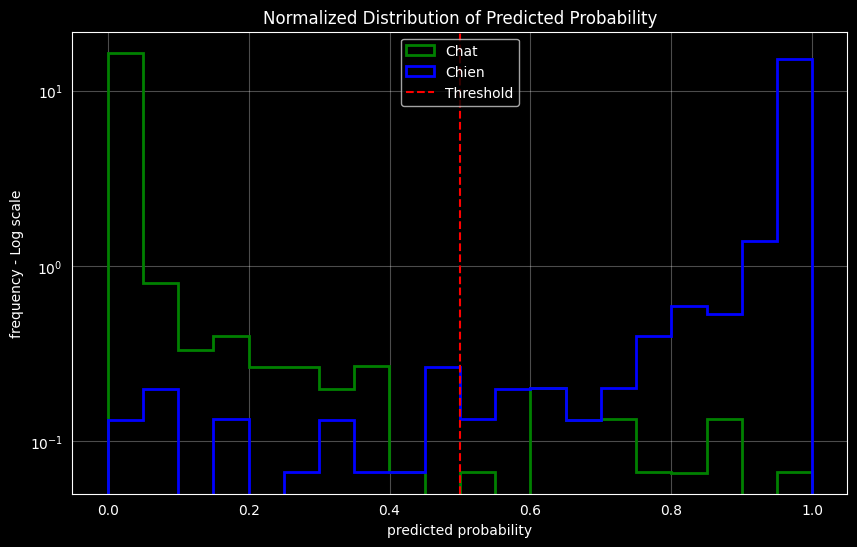

In [30]:
model = keras.models.load_model('cats_dogs_model.keras')
y_pred_proba = model.predict(X_test).flatten()
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

prob_chats = y_pred_proba[y_test == 0]

prob_chiens = y_pred_proba[y_test == 1]
# print(prob_chats)
# print(prob_chiens)
range = (0.0, 1.0)

plt.figure(figsize=(10, 6))
plt.hist(prob_chats, bins=20, histtype='step', color="green", label="Chat", linewidth=2, density=True, log=True,range=range)
plt.hist(prob_chiens, bins=20, histtype='step', color="blue", label="Chien", linewidth=2, density=True, log=True,range=range)

plt.axvline(0.5, color="red", linestyle="--", label="Threshold")
plt.xlabel("predicted probability")
plt.ylabel("frequency - Log scale")
plt.title("Normalized Distribution of Predicted Probability")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()